# Environment Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy.optimize import minimize
from sklearn.metrics import r2_score, mean_squared_error 
import warnings 

warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120, 'axes.grid': True,
                    'grid.alpha':0.3, 'font.size': 11})
print("All libraries loaded successfully.")


All libraries loaded successfully.


# Section A: Data Engineering and Preprocessing
## Dataset
Daily zero-coupon bond yields across 9 maturity tenors:

|**Column** |	**Maturity**|
|-----------|---------------|
|ZC025YR	|3 Months (0.25 yr)|
|ZC050YR	|6 Months (0.50 yr)|
|ZC075YR	|9 Months (0.75 yr)|
|ZC100YR	|1 Year|
|ZC200YR	|2 Years|
|ZC500YR	|5 Years|
|ZC1000YR	|10 Years|
|ZC2000YR	|20 Years|
|ZC3000YR	|30 Years|

**Training set**: 2016–2024 (all 9 maturities)

**Test set**: 2024–2026 (only 6M–2Y available as targets; 3M used as input only)

In [3]:
#     Load raw data
# Place the three CSV files in the same directory as this notebook.
TRAIN_PATH = 'train_data.csv'
TEST_PATH = 'test_data.csv'
TEST_3M_PATH = 'test_data_3M.csv'

train_raw = pd.read_csv(TRAIN_PATH)
test_raw = pd.read_csv(TEST_PATH)
test_3m = pd.read_csv(TEST_3M_PATH)

# Strip any Leading/trailing spaces from column names (common CSV quirk)
for df in [train_raw, test_raw, test_3m]:
    df.columns = df.columns.str.strip()

print("=== Training Data ===")
print(f"Shape: {train_raw.shape} | Date range: {train_raw['Date'].min()} -- {train_raw['Date'].max()}")    
print()
print("=== Test Data ===")
print(f"Shape: {test_raw.shape} | Date range: {test_raw['Date'].min()} -- {test_raw['Date'].max()}")
print()
print("Missing values in training set:")
print(train_raw.isnull().sum())

=== Training Data ===
Shape: (1976, 10) | Date range: 2016-05-19 -- 2024-04-26

=== Test Data ===
Shape: (495, 6) | Date range: 2024-04-29 -- 2026-04-29

Missing values in training set:
Date        0
ZC025YR     0
ZC050YR     0
ZC075YR     0
ZC100YR     0
ZC200YR     0
ZC500YR     0
ZC1000YR    0
ZC2000YR    0
ZC3000YR    0
dtype: int64


In [4]:
# ── Maturity mapping ──────────────────────────────────────────────────────
MATURITY_MAP = {
    'ZC025YR': 0.25, 'ZC050YR': 0.50, 'ZC075YR': 0.75,
    'ZC100YR': 1.00, 'ZC200YR': 2.00, 'ZC500YR': 5.00,
    'ZC1000YR': 10.0, 'ZC2000YR': 20.0, 'ZC3000YR': 30.0,
}
TRAIN_COLS = list(MATURITY_MAP.keys())
TRAIN_MATS = np.array(list(MATURITY_MAP.values()))

# These are the maturities we predict in the test set (targets)
TEST_PRED_COLS = ['ZC050YR', 'ZC075YR', 'ZC100YR', 'ZC200YR']
TEST_PRED_MATS = np.array([0.50, 0.75, 1.00, 2.00])

In [5]:
def clean_yields(df):
    """
    Clean a yield dataframe:
    1. Parse dates and sort chronologically.
    2. Replace zeros / negatives with NaN (invalid yields).
    3. Winsorise at 1st–99th percentile to dampen outliers.
    4. Linearly interpolate gaps; forward/back fill at edges.
    """
    df = df.copy()
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    for col in [c for c in df.columns if c != 'Date']:
        # Zero or negative yields are economically impossible
        df[col] = df[col].replace(0, np.nan).where(df[col] > 0, np.nan)
        # Clip extreme values at 1st / 99th percentile
        q_lo, q_hi = df[col].quantile(0.01), df[col].quantile(0.99)
        df[col] = df[col].clip(lower=q_lo, upper=q_hi)
        # Fill remaining gaps linearly
        df[col] = df[col].interpolate(method='linear').ffill().bfill()

    return df


train    = clean_yields(train_raw)
test     = clean_yields(test_raw)
test_3m  = clean_yields(test_3m)

print(f"Train: {len(train)} rows | NaN remaining: {train.isnull().sum().sum()}")
print(f"Test : {len(test)}  rows | NaN remaining: {test.isnull().sum().sum()}")

Train: 1976 rows | NaN remaining: 0
Test : 495  rows | NaN remaining: 0


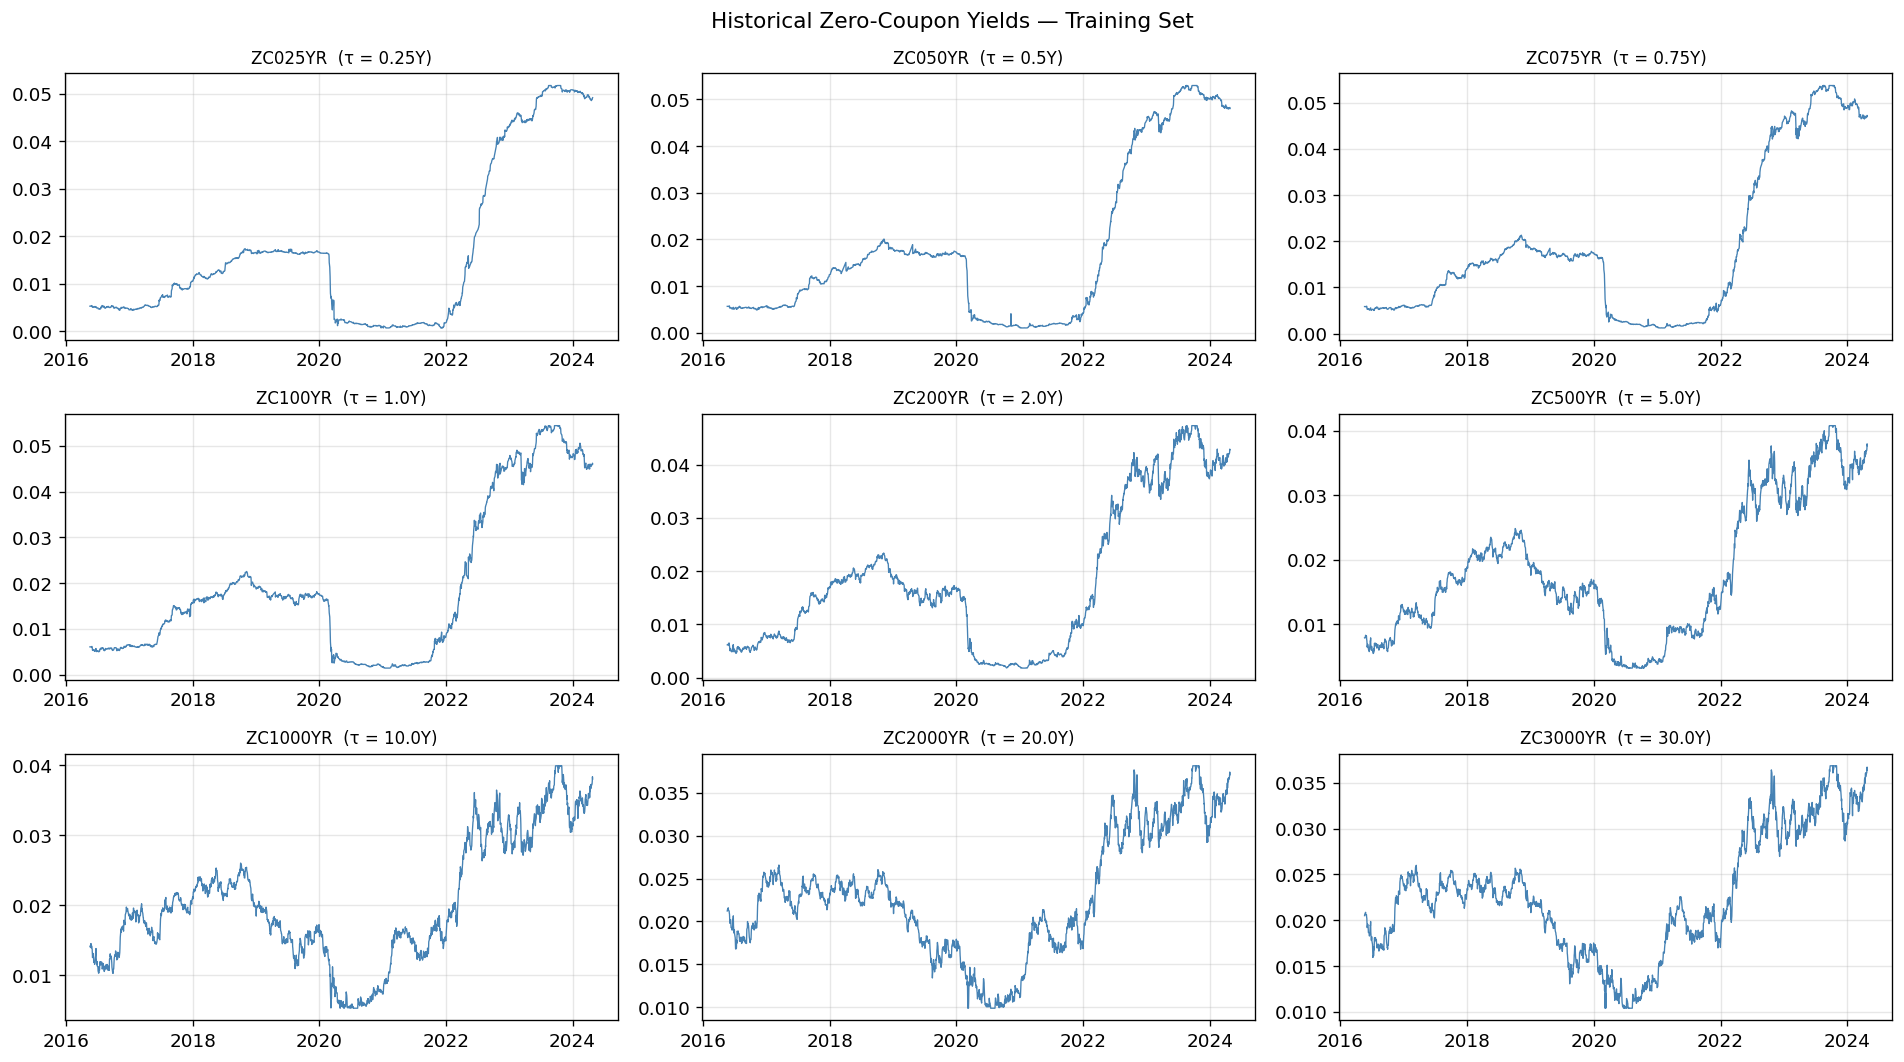

In [6]:
# ── Historical yield plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 9))
axes = axes.ravel()
for i, (col, tau) in enumerate(MATURITY_MAP.items()):
    axes[i].plot(train['Date'], train[col], linewidth=0.8, color='steelblue')
    axes[i].set_title(f'{col}  (τ = {tau}Y)', fontsize=10)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(2))
plt.suptitle('Historical Zero-Coupon Yields — Training Set', fontsize=13)
plt.tight_layout()
plt.show()

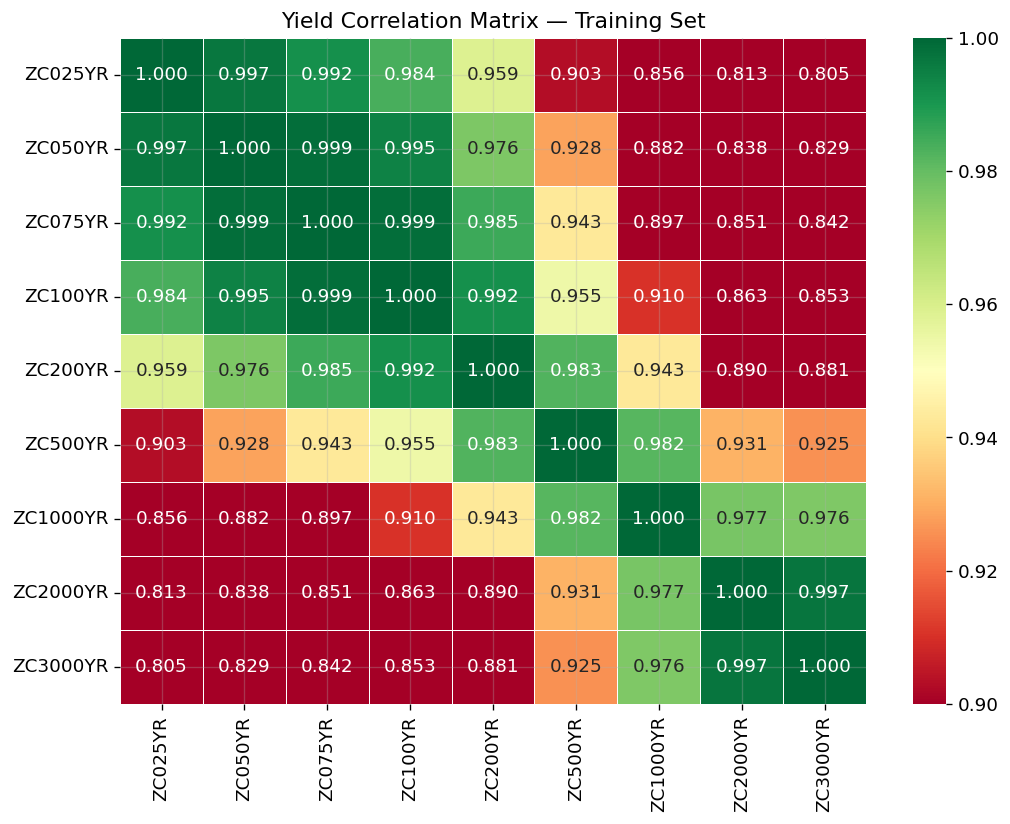

All pairwise correlations > 0.95 → strong support for single-factor CIR.


In [7]:
# ── Correlation heatmap ────────────────────────────────────────────────────
# High cross-maturity correlations are the empirical justification for using
# a single-factor model: one latent rate drives the whole curve.
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(train[TRAIN_COLS].corr(), annot=True, fmt='.3f',
            cmap='RdYlGn', vmin=0.9, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Yield Correlation Matrix — Training Set')
plt.tight_layout()
plt.show()
print("All pairwise correlations > 0.95 → strong support for single-factor CIR.")